In [130]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/learn_ML_LKS/csv/Data Set SMK - Data Fix.csv")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75 entries, 0 to 74
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   NIK                75 non-null     float64
 1   Nama               75 non-null     object 
 2   TTL                75 non-null     object 
 3   Status Hubungan    75 non-null     object 
 4   Status Perkawinan  75 non-null     object 
 5   Gaji               75 non-null     object 
 6   Jenis Pekerjaan    75 non-null     object 
 7   Agama              75 non-null     object 
 8   Jenis Makanan      75 non-null     object 
 9   Kode Rumah         75 non-null     object 
 10  Luas Rumah         75 non-null     int64  
dtypes: float64(1), int64(1), object(9)
memory usage: 6.6+ KB


In [131]:
df.head()

,NIK,Nama,TTL,Status Hubungan,Status Perkawinan,Gaji,Jenis Pekerjaan,Agama,Jenis Makanan,Kode Rumah,Luas Rumah
0,3.359990e+15,Pak Sutajo,"jember, 28-07-1933",Kepala Keluarga,kawin,"Rp3.000.000,00",Pensiunan,Islam,rawon,A1,280
1,3.357030e+15,Bu Sutajo,"jember, 12-07-1940",Istri,kawin,"Rp0,00",Tidak Bekerja,Islam,rawon,A1,280
2,3.356440e+15,Pak Jais,"jember, 01-07-1963",Kepala Keluarga,kawin,"Rp3.000.000,00",Pensiunan,Islam,bakso,B1,240
3,3.355550e+15,Bu Jais,"jember, 15-03-1966",Istri,kawin,"Rp0,00",Tidak Bekerja,Islam,bakso,B1,240
4,3.354210e+15,Pak Pardi,"jember, 14-12-1965",Kepala Keluarga,kawin,"Rp3.000.000,00",Pensiunan,Islam,rawon,B2,240


In [132]:
df.drop(columns=["NIK", "Agama"], inplace=True)
df.head()

,Nama,TTL,Status Hubungan,Status Perkawinan,Gaji,Jenis Pekerjaan,Jenis Makanan,Kode Rumah,Luas Rumah
0,Pak Sutajo,"jember, 28-07-1933",Kepala Keluarga,kawin,"Rp3.000.000,00",Pensiunan,rawon,A1,280
1,Bu Sutajo,"jember, 12-07-1940",Istri,kawin,"Rp0,00",Tidak Bekerja,rawon,A1,280
2,Pak Jais,"jember, 01-07-1963",Kepala Keluarga,kawin,"Rp3.000.000,00",Pensiunan,bakso,B1,240
3,Bu Jais,"jember, 15-03-1966",Istri,kawin,"Rp0,00",Tidak Bekerja,bakso,B1,240
4,Pak Pardi,"jember, 14-12-1965",Kepala Keluarga,kawin,"Rp3.000.000,00",Pensiunan,rawon,B2,240


In [133]:
# Clean to datetime

month_to_num = {
    "januari": 1, "februari": 2, "maret": 3, "april": 4,
    "mei": 5, "juni": 6, "juli": 7, "agustus": 8,
    "september": 9, "oktober": 10, "november": 11, "desember": 12
}

def ttl_to_datetime(row: str):
  try:
    _, date = row.split(",", 1)
    return pd.to_datetime(date.strip())
  except ValueError:
    each = date.strip().split(" ")
    return pd.to_datetime(f"{each[0]}-{month_to_num[each[1].lower()]}-{each[2]}")

ttl_to_datetime("jember, 01-07-1963")

df["TTL"] = df["TTL"].apply(ttl_to_datetime)

# Add Age
df["Umur"] = 2025 - df["TTL"].dt.year

cols = df.columns.to_list()
cols.remove("Umur")
cols.insert(2, "Umur")
df = df[cols]

<ipython-input-133-032d66633d88>:12: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  return pd.to_datetime(date.strip())
<ipython-input-133-032d66633d88>:15: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  return pd.to_datetime(f"{each[0]}-{month_to_num[each[1].lower()]}-{each[2]}")


In [134]:
# Clean gaji

def clean_salary(row: str):
  salary = row.split("Rp")[1].replace(".", "")
  return float(salary.replace(",", "."),)

df["Gaji"] = df["Gaji"].apply(clean_salary)

In [135]:
df.head()

,Nama,TTL,Umur,Status Hubungan,Status Perkawinan,Gaji,Jenis Pekerjaan,Jenis Makanan,Kode Rumah,Luas Rumah
0,Pak Sutajo,1933-07-28,92,Kepala Keluarga,kawin,3000000.0,Pensiunan,rawon,A1,280
1,Bu Sutajo,1940-12-07,85,Istri,kawin,0.0,Tidak Bekerja,rawon,A1,280
2,Pak Jais,1963-01-07,62,Kepala Keluarga,kawin,3000000.0,Pensiunan,bakso,B1,240
3,Bu Jais,1966-03-15,59,Istri,kawin,0.0,Tidak Bekerja,bakso,B1,240
4,Pak Pardi,1965-12-14,60,Kepala Keluarga,kawin,3000000.0,Pensiunan,rawon,B2,240


# Try to make graph

In [136]:
!pip install networkx

In [137]:
house_code = ["A1","A1","B1","B1","B2","B2","B3","B3","C1","C1","C2","C2","C3","C3","C4","C4","C5","C5","C6","C6","C7","C7","C8","C8","C9","C9","C10","C10","C11","C11","C12","C12","C13","C13","C14","C14","C1","C1","C2","C2","C2","C3","C3","C3","C3","C4","C4","C5","C5","C5","C6","C6","C6","C6","C7","C7","C7","C8","C8","C8","C9","C9","C10","C10","C10","C11","C11","C12","C12","C12","C13","C13","C13","C14","C14",]
house_code_df = pd.DataFrame(house_code)
house_code_df_unique = house_code_df[0].unique()
house_code_df_unique

array(['A1', 'B1', 'B2', 'B3', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7',
       'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14'], dtype=object)

In [138]:
# Who can give THR / house?

can_give_thr = {}

for h_c in house_code_df_unique:
  salary = df[df["Kode Rumah"] == h_c]["Gaji"].to_numpy().sum()
  if salary >= 10000000.00:
    can_give_thr[h_c] = salary

can_give_thr

{'C1': 14322615.16,
 'C2': 35606002.41,
 'C4': 15655977.48,
 'C5': 18219718.71,
 'C9': 10699818.46,
 'C10': 10285054.9,
 'C13': 13282358.36,
 'C14': 13624923.16}

In [139]:
def calc_time_by_width_house(row: int):
  if row > 200:
    return 30
  else:
    return 15

mean_house = df.groupby("Kode Rumah")["Luas Rumah"].mean()
width_to_calc_time = mean_house.apply(lambda x: calc_time_by_width_house(x))
width_to_calc_time

,Luas Rumah
Kode Rumah,
A1,30
B1,30
B2,30
B3,30
C1,15
C10,15
C11,15
C12,15
C13,30


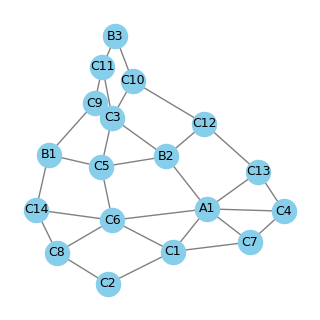

In [140]:
import networkx as nx
import matplotlib.pyplot as plt

house_code = ['A1', 'B1', 'B2', 'B3', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7',
       'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14']
graph = {
    "A1": ["C6", "C1", "C7", "C4", "C13", "B2"],
    "B2": ["A1", "C5", "C3", "C12"],
    "C5": ["C6", "B1", "C3", "B2"],
    "B1": ["C14", "C5", "C9"],
    "C9": ["B1", "C3", "C11"],
    "C11": ["C9", "C3", "B3"],
    "B3": ["C11", "C10"],
    "C10": ["B3", "C12", "C3"],
    "C12": ["C10", "B2", "C13"],
    "C13": ["C12", "A1", "C4"],
    "C4": ["A1", "C7", "C13"],
    "C7": ["A1", "C1", "C4"],
    "C1": ["C7", "A1", "C6", "C2"],
    "C2": ["C1", "C8",],
    "C8": ["C2", "C6", "C14"],
    "C14": ["B1", "C8", "C6"],
    "C6": ["C14", "C8", "C1", "C5", "A1"]
}

G = nx.Graph()

G.add_nodes_from(house_code)

for node, neighbors in graph.items():
  for neighbor in neighbors:
    G.add_edge(node, neighbor)

plt.figure(figsize=(3, 3))
nx.draw(G, with_labels=True, node_color='skyblue', edge_color='gray', node_size=300, font_size=9)
plt.show()

In [141]:
# Get Home Priority

level_list = {
    "Pak Sutajo": 1,
    "Pak Jais": 2,
    "Pak Pardi": 2,
    "Pak Udin": 2
}

your_home = "C14"

home_priorities = dict()

# home_priority_list = df[(df["Status Hubungan"] == "Kepala Keluarga") & (df["Kode Rumah"] != your_home)].sort_values(by="Umur", ascending=False)["Kode Rumah"].to_list()
home_priority_df = df[(df["Status Hubungan"] == "Kepala Keluarga")].sort_values(by="Umur", ascending=False)[["Kode Rumah", "Nama"]].to_numpy().tolist()
for row in home_priority_df:
  if row[1] in level_list:
    home_priorities[row[0]] = level_list[row[1]]
  else:
    home_priorities[row[0]] = 3

home_priorities

{'A1': 1,
 'B1': 2,
 'B2': 2,
 'B3': 2,
 'C1': 3,
 'C2': 3,
 'C6': 3,
 'C3': 3,
 'C4': 3,
 'C5': 3,
 'C9': 3,
 'C7': 3,
 'C8': 3,
 'C10': 3,
 'C11': 3,
 'C12': 3,
 'C13': 3,
 'C14': 3}

In [142]:
# Add properties

for h_c in house_code_df_unique:
  G.add_node(h_c, house={
      "times": width_to_calc_time[h_c],
      "food": df[(df["Kode Rumah"] == h_c) & (df['Status Hubungan'] == "Kepala Keluarga")]["Jenis Makanan"].to_list()[0],
      "level": home_priorities[h_c]
  })

In [143]:
edge_index = [
    ('C14', 'B1', 15),('C14', 'C6', 20),('C14', 'C8', 25),
    ('C8', 'C6', 15),('C8', 'C2', 25),
    ('C2', 'C1', 25),
    ('C1', 'C6', 25),('C1', 'C7', 20),('C1', 'A1', 20),
    ('C7', 'C4', 25),('C7', 'A1', 25),
    ('C4', 'A1', 25),('C4', 'C13', 20),
    ('A1', 'C13', 20),('A1', 'B2', 10),
    ('C6', 'A1', 25),('C6', 'C5', 10),
    ('C5', 'B1', 15),('C5', 'B2', 15),('C5', 'C3', 25),
    ('B2', 'C12', 15),('B2', 'C3', 10),
    ('C12', 'C13', 20),('C12', 'C10', 20),
    ('C10', 'B3', 10),('C10', 'C3', 15),
    ('C3', 'C9', 25),('C3', 'C11', 15),
    ('C9', 'B1', 15),('C9', 'C11', 15),
    ('C11', 'B3', 25),

]

G.add_weighted_edges_from(edge_index)

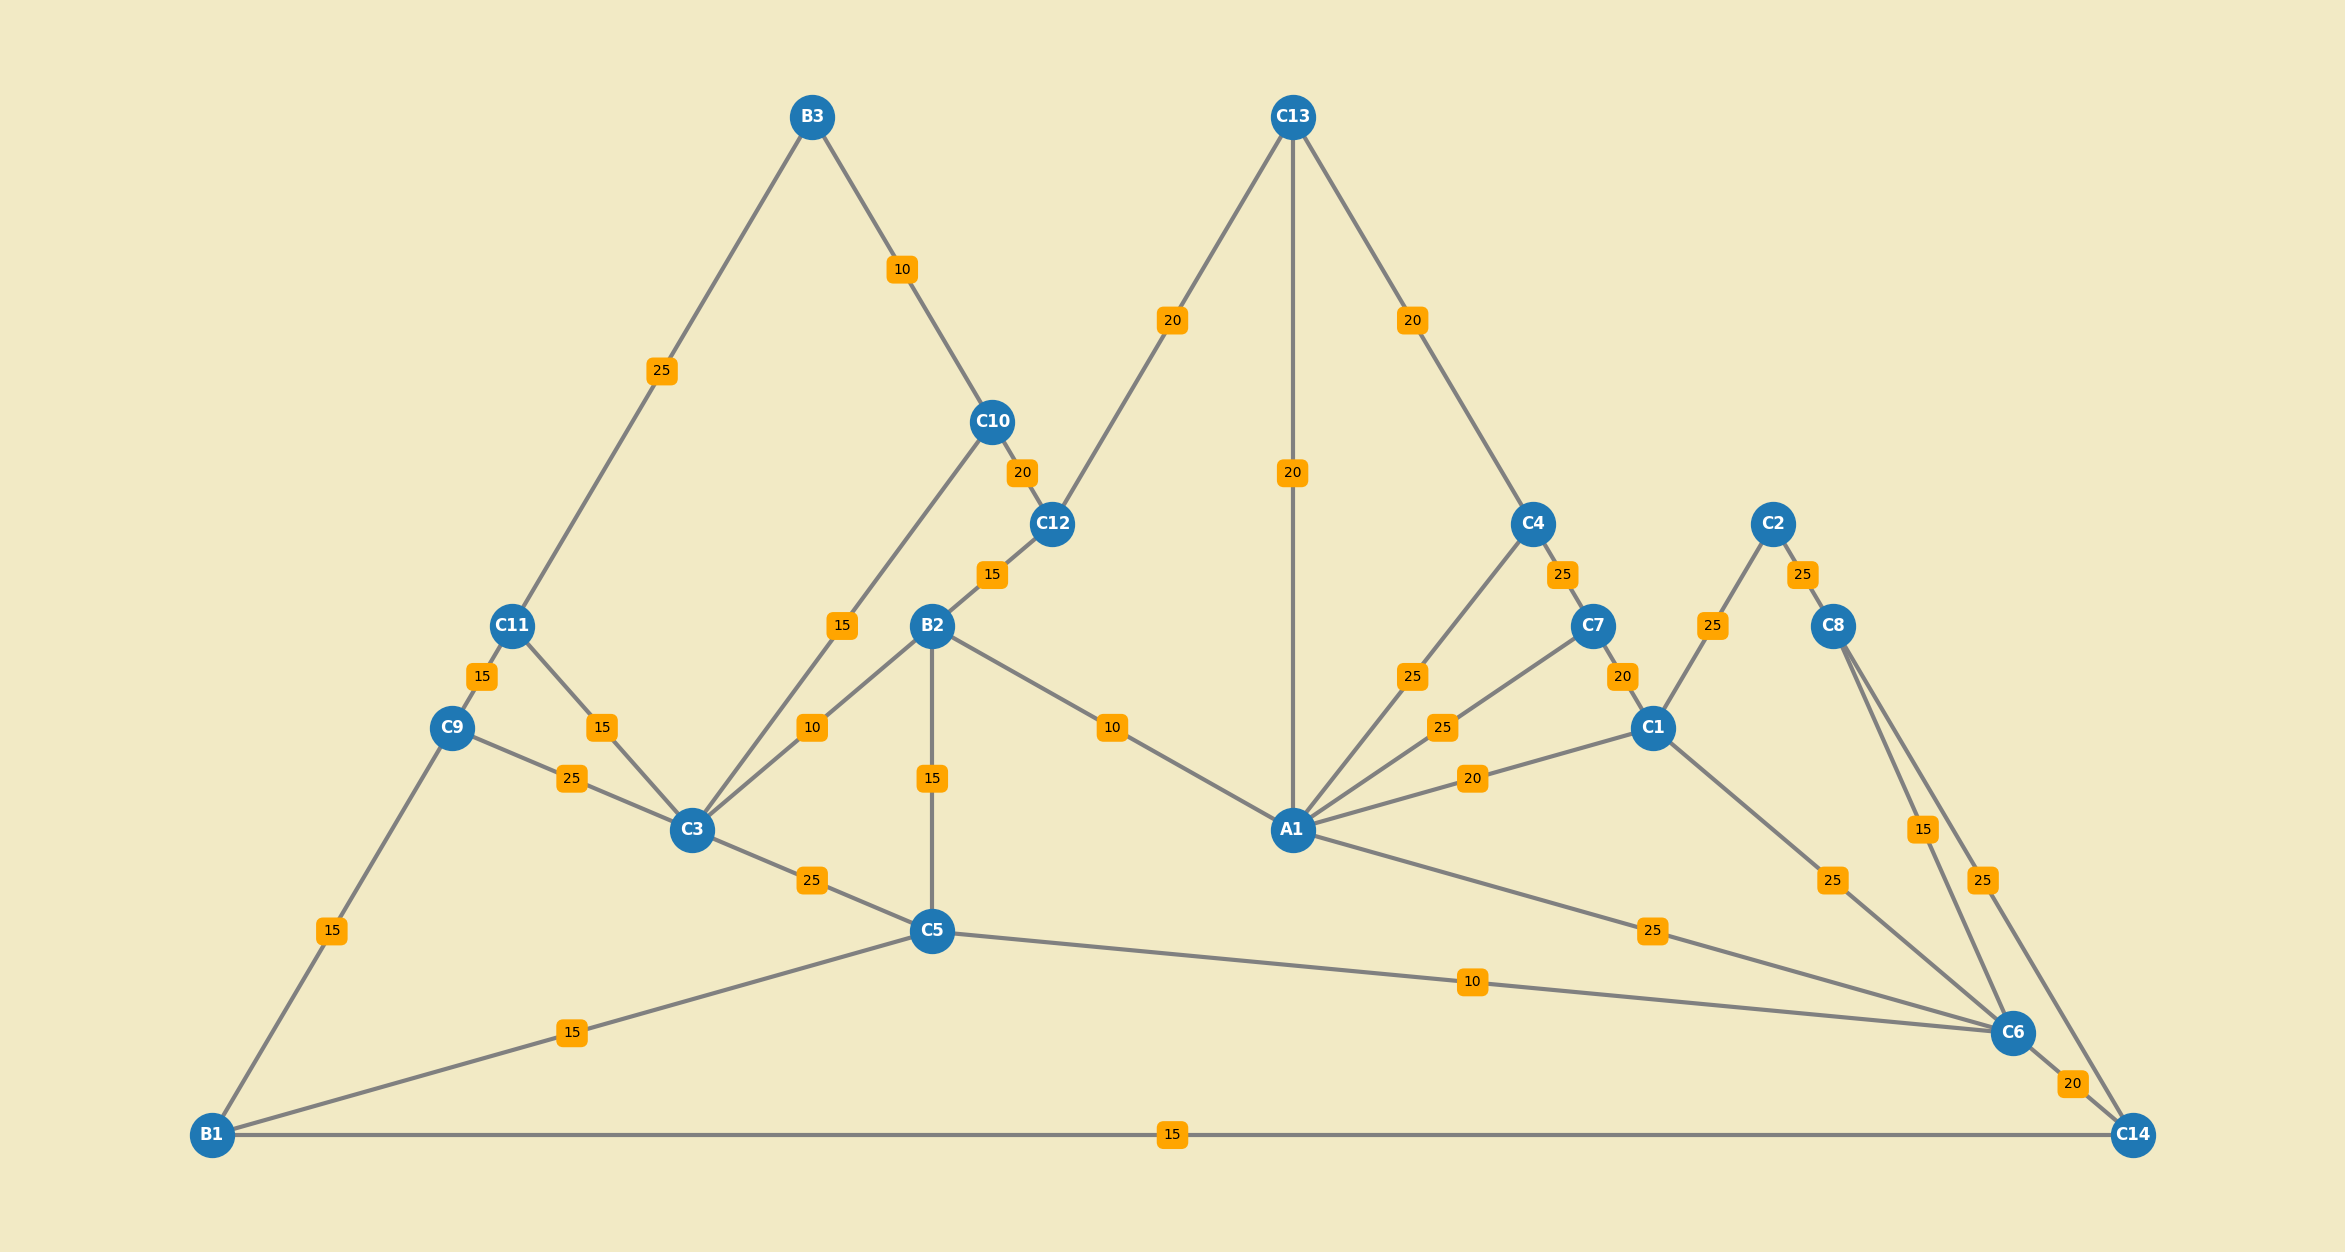

In [144]:
fig, ax = plt.subplots(figsize=(30, 16))

pos = nx.planar_layout(G)
edge_labels = nx.get_edge_attributes(G, "weight")

nx.draw(G,pos, with_labels=True, ax=ax, node_size=1000, font_size=12,
        font_color='w', font_weight='bold', width=3, edge_color='gray')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, rotate=False, bbox={"color":"orange", "boxstyle": "round", "linewidth": 4})
fig.set_facecolor('#F2EAC5')

In [145]:
data = dict(G.nodes(data=True))
data

{'A1': {'house': {'times': 30, 'food': 'rawon', 'level': 1}},
 'B1': {'house': {'times': 30, 'food': 'bakso', 'level': 2}},
 'B2': {'house': {'times': 30, 'food': 'rawon', 'level': 2}},
 'B3': {'house': {'times': 30, 'food': 'ayam bakar', 'level': 2}},
 'C1': {'house': {'times': 15, 'food': 'bakso', 'level': 3}},
 'C2': {'house': {'times': 30, 'food': 'opor', 'level': 3}},
 'C3': {'house': {'times': 15, 'food': 'opor', 'level': 3}},
 'C4': {'house': {'times': 15, 'food': 'bakso', 'level': 3}},
 'C5': {'house': {'times': 30, 'food': 'rawon', 'level': 3}},
 'C6': {'house': {'times': 15, 'food': 'ayam bakar', 'level': 3}},
 'C7': {'house': {'times': 15, 'food': 'opor', 'level': 3}},
 'C8': {'house': {'times': 30, 'food': 'ayam bakar', 'level': 3}},
 'C9': {'house': {'times': 30, 'food': 'bakso', 'level': 3}},
 'C10': {'house': {'times': 15, 'food': 'soto', 'level': 3}},
 'C11': {'house': {'times': 15, 'food': 'opor', 'level': 3}},
 'C12': {'house': {'times': 15, 'food': 'soto', 'level': 3

# Try to simulate

In [207]:
def get_nearest_target(current_home, remaining_house):
  nearest_home = None
  shorted_distance = float("inf")
  lowest_level = float("inf")

  for home in remaining_house:
    if home == current_home:
      continue
    distance = nx.astar_path_length(G, current_home, home, weight="weight")
    level = data[home]["house"]["level"]
    if (level < lowest_level) or (level == lowest_level and (distance < shorted_distance)):
      nearest_home = home
      shorted_distance = distance
      lowest_level = level

  return nearest_home

def get_path(start: str):
  visited = {"Day-1": []}
  i = 0
  times = 0
  current_target = start
  check_point = current_target

  remaining_house = sorted(home_priorities.keys(), key=lambda x: home_priorities[x])

  for h in home_priorities:
    foods = []
    thr = []

    if times >= 480:
      check_point = start
      times = 0
      i += 1
      visited[f"Day-{i+1}"] = []
      continue

    current_data = data[h]["house"]
    current_target = get_nearest_target(check_point, remaining_house)

    sp = nx.astar_path(G, check_point, current_target, heuristic=lambda u, v: home_priorities[u], weight="weight")
    time_in_house = current_data["times"]
    distance = nx.astar_path_length(G, check_point, current_target, weight="weight")
    times += distance + time_in_house

    visited[f"Day-{i+1}"].append({
        "time_in_house": time_in_house,
        "distance": distance,
        "path": sp,
        "food": current_data["food"],
        "thr": 50000 if current_target in can_give_thr else 0
    })

    check_point = sp[-1]
    remaining_house.remove(current_target)

  return visited

paths = get_path("C14")
paths

{'Day-1': [{'time_in_house': 30,
   'distance': 45,
   'path': ['C14', 'C6', 'A1'],
   'food': 'rawon',
   'thr': 0},
  {'time_in_house': 30,
   'distance': 10,
   'path': ['A1', 'B2'],
   'food': 'bakso',
   'thr': 0},
  {'time_in_house': 30,
   'distance': 30,
   'path': ['B2', 'C5', 'B1'],
   'food': 'rawon',
   'thr': 0},
  {'time_in_house': 30,
   'distance': 55,
   'path': ['B1', 'C9', 'C11', 'B3'],
   'food': 'ayam bakar',
   'thr': 0},
  {'time_in_house': 15,
   'distance': 10,
   'path': ['B3', 'C10'],
   'food': 'bakso',
   'thr': 50000},
  {'time_in_house': 30,
   'distance': 15,
   'path': ['C10', 'C3'],
   'food': 'opor',
   'thr': 0},
  {'time_in_house': 15,
   'distance': 15,
   'path': ['C3', 'C11'],
   'food': 'ayam bakar',
   'thr': 0},
  {'time_in_house': 15,
   'distance': 15,
   'path': ['C11', 'C9'],
   'food': 'opor',
   'thr': 50000},
  {'time_in_house': 15,
   'distance': 30,
   'path': ['C9', 'B1', 'C5'],
   'food': 'bakso',
   'thr': 50000},
  {'time_in_house

# Try to make readable

In [225]:
def got_top_food(foods: list, top: None):
  print(foods)
  tmp = {}
  for food in foods:
    if food in tmp:
      tmp[food] += 1
    else:
      tmp[food] = 1

  most_common = []
  for key, val in tmp.items():
    if val > top:
      top = val
      tmp[val] = [key]
    elif val == top:
      most_common.append(key)
  return most_common

for key, val in paths.items():
    print(f"\n{'#' * 50} {key} {'#' * 50}")
    print(f"{'Start':<6} {'End':<6} {'Route':<30} {'Distance':<10} {'Time in House':<15} {'Total Time':<15} {'food':<15} {'THR':<10}")
    print("-" * 107)

    for row in val:
        if not row:
            continue
        route_path = " -> ".join(row["path"])
        start, end = row["path"][0], row["path"][-1]
        distance, time_in_house = row["distance"], row["time_in_house"]
        total_time = distance + time_in_house
        food, thr = row["food"], row["thr"]

        print(f"{start:<6} {end:<6} {route_path:<30} {distance:<10} {time_in_house:<15} {total_time:<15} {food:<15} {thr:<10}")

    print("-" * 107)
    print(f"Top food: {got_top_food(food, 5)}")


################################################## Day-1 ##################################################
Start  End    Route                          Distance   Time in House   Total Time      food            THR       
-----------------------------------------------------------------------------------------------------------
C14    A1     C14 -> C6 -> A1                45         30              75              rawon           0         
A1     B2     A1 -> B2                       10         30              40              bakso           0         
B2     B1     B2 -> C5 -> B1                 30         30              60              rawon           0         
B1     B3     B1 -> C9 -> C11 -> B3          55         30              85              ayam bakar      0         
B3     C10    B3 -> C10                      10         15              25              bakso           50000     
C10    C3     C10 -> C3                      15         30              45              opor 